# 03 · Merge — Sèrie Temporal Final de Població (1993–2025)

**Inputs:**
- `data/clean/peacenow_population_long.csv` — Peace Now (1993–2024, font principal)
- `data/clean/jvl_long.csv` — Jewish Virtual Library (únicament 2025)

**Output:** `data/clean/population_final.csv`

---
## Metodologia

| Període | Font | Justificació |
|---------|------|-------------|
| 1993–2024 | Peace Now | Font principal: 148 assentaments, metodologia homogènia, variables geoespacials |
| 2025 | JVL / CBS | Única font disponible per a l'any 2025 |

El canvi de font es documenta amb una anotació a la visualització.  
La columna `source` permet identificar l'origen de cada registre.

---
## Normalització de noms

Els noms de Peace Now i JVL provenen de transliteracions independents.  
El mapping d'aquest notebook és la **referència definitiva** del projecte:  
qualsevol notebook posterior que necessiti creuar noms ha d'importar o reutilitzar aquest mapping.


## 1. Importació de llibreries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

print("Llibreries carregades correctament")

Llibreries carregades correctament


## 2. Càrrega dels datasets

In [2]:
pn  = pd.read_csv("data/clean/peacenow_population_long.csv")
jvl = pd.read_csv("data/clean/jvl_long.csv")

for name, df in [("Peace Now", pn), ("JVL", jvl)]:
    print(f"{name:12s} → {df.shape[0]:5d} registres | "
          f"anys {df['year'].min()}–{df['year'].max()} | "
          f"{df['settlement'].nunique()} assentaments | "
          f"source: {df['source'].unique().tolist()}")

Peace Now    →  3861 registres | anys 1993–2024 | 132 assentaments | source: ['peace_now']
JVL          →   147 registres | anys 2025–2025 | 147 assentaments | source: ['jvl']


## 3. Normalització de noms

Peace Now i JVL utilitzen transliteracions independents.  
Apliquem un mapping sobre els noms de JVL per fer-los coincidir amb Peace Now,  
que és la font principal i la referència de noms del projecte.

**Criteri:** si un nom de JVL no apareix a Peace Now, s'afegeix al mapping.  
Els noms de Peace Now no es modifiquen mai.


In [3]:
# Mapping: nom JVL → nom Peace Now (referència)
# Construït comparant les dues llistes de noms i validat manualment.
NAME_MAPPING_JVL = {
    # Variants de grafies
    "Modi'in Illit":       "Modi'in Ilit",
    "Giv'at Ze'ev":        "Givat Ze'ev",
    "Ma'ale Adumim":       "Ma'ale Adumim",    # igual — verificar
    "Kochav Hashahar":     "Kochav Ha'shachar",
    "Kochav Ya'akov":      "Kochav Ya'akov",   # igual — verificar
    "Beit El":             "Beit El",           # igual — verificar
    "Sha'arei Tikva":      "Sha'arei Tikva",   # igual — verificar
    "Shaar Shomron":       "Shaar Shomron",    # igual — verificar
    "Geva Binyamin":       "Geva Binyamin (aka Adam)",
    "Adam":                "Geva Binyamin (aka Adam)",
    "Metzadot Yehuda":     "Yatir (aka Metzadot Yehuda)",
    "Yatir":               "Yatir (aka Metzadot Yehuda)",
    "Tekoa":               "Tko'a",
    "Elon Moreh":          "Elon More",
    "Har Gilo":            "Har Gilo",         # igual — verificar
    "Psagot":              "Psagot",           # igual — verificar
    "Nokdim":              "Nokdim",           # igual — verificar
}

def normalize_jvl_names(df, mapping=NAME_MAPPING_JVL):
    """Aplica el mapping de noms sobre la columna 'settlement' de JVL."""
    df = df.copy()
    df["settlement"] = df["settlement"].str.strip().replace(mapping)
    return df

jvl_norm = normalize_jvl_names(jvl)

# Diagnòstic: quants noms de JVL coincideixen amb Peace Now?
pn_names  = set(pn["settlement"].unique())
jvl_names = set(jvl_norm["settlement"].unique())

only_jvl = jvl_names - pn_names
only_pn  = pn_names - jvl_names

print(f"Noms a Peace Now:                 {len(pn_names)}")
print(f"Noms a JVL (normalitzats):        {len(jvl_names)}")
print(f"Coincidències:                    {len(pn_names & jvl_names)}")
print(f"\nNoms a JVL però NO a Peace Now ({len(only_jvl)}):")
for n in sorted(only_jvl):
    print(f"  '{n}'")
print(f"\nNota: els noms exclusius de JVL s'incorporen igualment a la sèrie.")
print(f"Poden ser assentaments nous o noms sense equivalent a Peace Now 2024.")

Noms a Peace Now:                 132
Noms a JVL (normalitzats):        147
Coincidències:                    70

Noms a JVL però NO a Peace Now (77):
  'Achya'
  'Adam (Geva)'
  'Adura'
  'Adurayim'
  'Alei (Elei) Zahav'
  'Almon (Anatot)'
  'Amichai'
  'Argeman'
  'Asael'
  'Avigael'
  'Avnet'
  'Bar Kochba'
  'Barkan'
  'Bekaot'
  'Bet Arye'
  'Bet Chagla'
  'Bet El'
  'Bet Ha'Arava'
  'Bet Horon'
  'Bet Yatir'
  'Carmei Zur'
  'Charsha'
  'Einav'
  'Elazar'
  'Elon (Alon) Shevut'
  'Emmanuel'
  'Fetzael'
  'Galgal'
  'Gittit'
  'Givon HaHadasha'
  'Gvaot Haroeh'
  'Hemdat'
  'Hermesh (Chermesh)'
  'Hevron'
  'Hinnanit (Chinanit)'
  'Ibey HaNachal'
  'Karnei Shomron^'
  'Kedar'
  'Kerm Raim'
  'Kfar HaOranim'
  'Kfar Tapuach'
  'Kochav HaShahar'
  'Kochav Yaakov'
  'Leshem'
  'Ma'ale Efrayim'
  'Maskiot'
  'Mehola'
  'Mesua'
  'Metzad-Asfar'
  'Mevuot Jericho'
  'Migron'
  'Mizpe Jericho'
  'Mizpe Shalem'
  'Na'aleh'
  'Naama'
  'Nachliel'
  'Neriya'
  'Netiv HaGedud'
  'Nofey Prat'

## 4. Construcció de la sèrie final

- **Peace Now 1993–2024:** font principal, sense modificacions de noms
- **JVL 2025:** noms normalitzats amb el mapping de la secció anterior
- **Cap solapament:** Peace Now arriba fins al 2024, JVL aporta únicament el 2025


In [4]:
BASE_COLS = ["settlement", "year", "population", "source"]

# Bloc 1: Peace Now 1993–2024
pn_out = pn[BASE_COLS].copy()

# Bloc 2: JVL 2025 (noms normalitzats)
jvl_out = jvl_norm[jvl_norm["year"] == 2025][BASE_COLS].copy()

# Sèrie final
df_final = pd.concat([pn_out, jvl_out], ignore_index=True)
df_final = df_final.sort_values(["settlement", "year"]).reset_index(drop=True)

print(f"Shape sèrie final: {df_final.shape}")
print(f"Anys:              {df_final['year'].min()}–{df_final['year'].max()}")
print(f"Assentaments:      {df_final['settlement'].nunique()}")
print(f"\nRegistres per any:")
print(df_final.groupby("year")["settlement"].count().to_string())

Shape sèrie final: (4008, 4)
Anys:              1993–2025
Assentaments:      209

Registres per any:
year
1993    105
1994    110
1995    110
1996    116
1997    116
1998    118
1999    118
2000    118
2001    118
2002    118
2003    119
2004    118
2005    119
2006    119
2007    119
2008    119
2009    121
2010    120
2011    121
2012    123
2013    125
2014    125
2015    126
2016    126
2017    126
2018    127
2019    127
2020    126
2021    127
2022    127
2023    127
2024    127
2025    147


## 5. Comprovacions finals

In [5]:
# Nuls
print("Nuls per columna:")
print(df_final.isnull().sum())
print()

# Duplicats
dups = df_final.duplicated(subset=["settlement", "year"])
print(f"Duplicats (settlement + year): {dups.sum()}")
if dups.sum() > 0:
    print(df_final[dups].to_string())
print()

# Un sol registre per assentament i any
check = df_final.groupby(["settlement", "year"]).size()
max_per_pair = check.max()
print(f"Màxim registres per assentament-any: {max_per_pair} (ha de ser 1)")
print()

# Rang temporal i cobertura
print(f"Any mínim: {df_final['year'].min()}")
print(f"Any màxim: {df_final['year'].max()}")
print(f"Anys coberts: {sorted(df_final['year'].unique())}")
print(f"Assentaments únics: {df_final['settlement'].nunique()}")
print()

# Fonts
print("Registres per font:")
print(df_final.groupby("source")["settlement"].count())

Nuls per columna:
settlement    0
year          0
population    0
source        0
dtype: int64

Duplicats (settlement + year): 0

Màxim registres per assentament-any: 1 (ha de ser 1)

Any mínim: 1993
Any màxim: 2025
Anys coberts: [np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Assentaments únics: 209

Registres per font:
source
jvl           147
peace_now    3861
Name: settlement, dtype: int64


In [6]:
# Verificació d'assentaments clau
print("Verificació d'assentaments clau (últim any disponible):")
for name in ["Ariel", "Beitar Illit", "Modi'in Ilit", "Ma'ale Adumim", "Efrat", "Ofra"]:
    rows = df_final[df_final["settlement"] == name]
    if len(rows) > 0:
        last = rows.iloc[-1]
        print(f"  {name}: {last['population']:,} hab. ({int(last['year'])}) — font: {last['source']}")
    else:
        print(f"  {name}: NOT FOUND")

Verificació d'assentaments clau (últim any disponible):
  Ariel: 22,273 hab. (2025) — font: jvl
  Beitar Illit: 74,760 hab. (2025) — font: jvl
  Modi'in Ilit: 92,339 hab. (2025) — font: jvl
  Ma'ale Adumim: 40,800 hab. (2025) — font: jvl
  Efrat: 13,502 hab. (2025) — font: jvl
  Ofra: 3,332 hab. (2025) — font: jvl


## 6. Visualització de la sèrie final

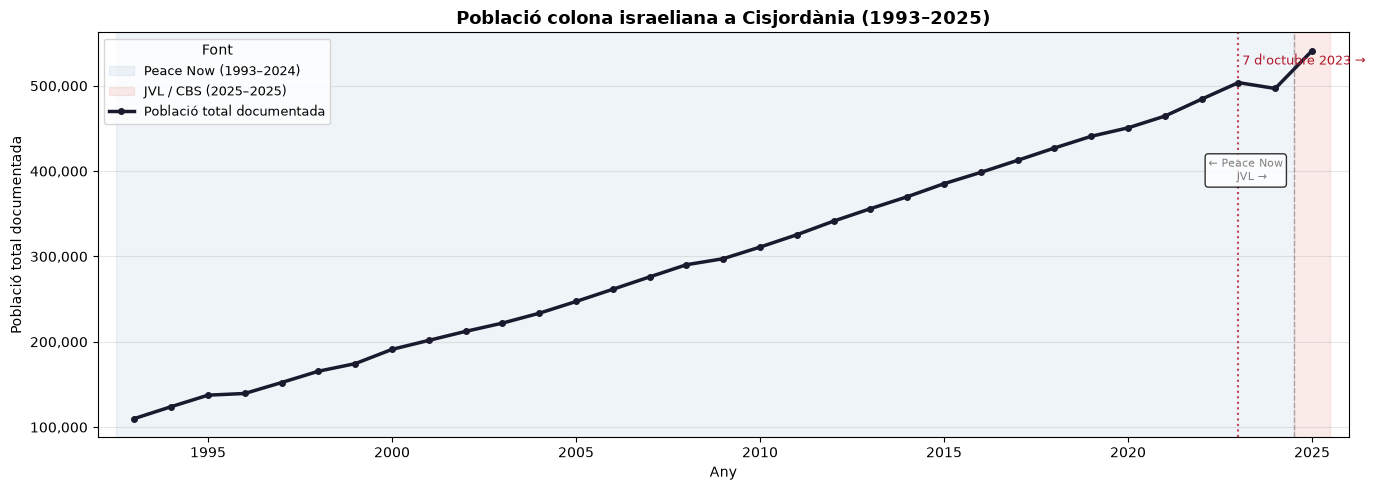

In [7]:
# Població total per any (suma de tots els assentaments documentats)
total = df_final.groupby("year")["population"].sum().reset_index()

# Anys de cada font per a les zones de fons
pn_min  = df_final[df_final["source"] == "peace_now"]["year"].min()
pn_max  = df_final[df_final["source"] == "peace_now"]["year"].max()
jvl_min = df_final[df_final["source"] == "jvl"]["year"].min()
jvl_max = df_final[df_final["source"] == "jvl"]["year"].max()

fig, ax = plt.subplots(figsize=(14, 5))

# Zones de fons per font
ax.axvspan(pn_min - 0.5, pn_max + 0.5,
           alpha=0.07, color="#2166ac",
           label=f"Peace Now ({pn_min}–{pn_max})")
ax.axvspan(jvl_min - 0.5, jvl_max + 0.5,
           alpha=0.12, color="#d6604d",
           label=f"JVL / CBS ({jvl_min}–{jvl_max})")

# Línia única de la sèrie
ax.plot(total["year"], total["population"],
        color="#1a1a2e", linewidth=2.5, marker="o", markersize=4,
        zorder=3, label="Població total documentada")

# Anotació: canvi de font
ax.axvline(x=2024.5, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.2, total["population"].max() * 0.72,
        "← Peace Now\n   JVL →",
        fontsize=8, color="gray", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Anotació: 7 d'octubre 2023
ax.axvline(x=2023, color="#b2182b", linestyle=":", linewidth=1.5, alpha=0.8)
ax.text(2023.1, total["population"].max() * 0.97,
        "7 d'octubre 2023 →",
        fontsize=9, color="#b2182b")

ax.set_title("Població colona israeliana a Cisjordània (1993–2025)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Any")
ax.set_ylabel("Població total documentada")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.set_xlim(1992, 2026)
ax.legend(title="Font", fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Exportació

In [8]:
os.makedirs("data/clean", exist_ok=True)

output_path = "data/clean/population_final.csv"
df_final.to_csv(output_path, index=False)

print(f"✓ Exportat: {output_path}")
print(f"  Registres:     {df_final.shape[0]:,}")
print(f"  Columnes:      {list(df_final.columns)}")
print(f"  Anys:          {df_final['year'].min()}–{df_final['year'].max()}")
print(f"  Assentaments:  {df_final['settlement'].nunique()}")
print(f"  Fonts:         {df_final['source'].unique().tolist()}")
print(f"\nAquest és el dataset definitiu per a totes les anàlisis i el dashboard.")

✓ Exportat: data/clean/population_final.csv
  Registres:     4,008
  Columnes:      ['settlement', 'year', 'population', 'source']
  Anys:          1993–2025
  Assentaments:  209
  Fonts:         ['jvl', 'peace_now']

Aquest és el dataset definitiu per a totes les anàlisis i el dashboard.
